# 03 — Field-controlled training

**Series:** field-controlled generation in 2D · notebook 3 of 5

Notebook 02 left us with a denoiser that obeys **one number**. This notebook fine-tunes it
to obey **one number per location**. It is the 2D mirror of **Algorithm 2** of Part II and
of `pipelines/fieldcontrolled/0003-porosity-field-training.py`.

The change to the model is: *nothing*. The change to the data is everything:

$$y = \operatorname{mean}(1-\omega) \in \mathbb{R}
\qquad\longrightarrow\qquad
y = \operatorname{avgpool}_F\bigl(\phi^*_{\mathbf{x},r}\bigr) \in \mathbb{R}^{32\times 32}$$

Four things have to be right, and each of them is a place where an implementation can
silently go wrong:

1. the patch and the field are cut from the **same location**;
2. the **same** random symmetry is applied to both;
3. the field is average-pooled by $F=8$ so it **lands on the latent grid**;
4. sampling positions are kept $R$ voxels away from the image border, so every field value
   is a genuine average over real rock.

---
## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import lightning
import lightning.pytorch.callbacks as pl_callbacks

import diffsci2.data
import diffsci2.models
import diffsci2.nets

import fcconfig as fc

fc.ensure_dirs()
torch.manual_seed(0)
np.random.seed(0)

DEVICE = fc.DEVICE
SCALAR_CKPT = os.path.join(fc.SCALAR_CKPT_DIR, "last.ckpt")
CKPT = os.path.join(fc.FIELD_CKPT_DIR, "last.ckpt")

assert os.path.exists(SCALAR_CKPT), "run notebook 02 first"
print(f"pretrained  <- {SCALAR_CKPT}")
print(f"fine-tuned  -> {CKPT}   (exists: {os.path.exists(CKPT)})")

pretrained  <- /home/ubuntu/repos/DiffSci2/notebooks/tutorials/fieldcontrolling/fcdata/checkpoints/scalar/last.ckpt
fine-tuned  -> /home/ubuntu/repos/DiffSci2/notebooks/tutorials/fieldcontrolling/fcdata/checkpoints/field/last.ckpt   (exists: True)


In [3]:
# --- fine-tuning knobs (Algorithm 2: low LR, warmup, cosine tail, EMA) ---
BATCH_SIZE = 16
DATASET_SIZE = 2 ** 12
MAX_EPOCHS = 30
LR = 5e-5                  # well below the 2e-4 used for pretraining
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
WARMUP_EPOCHS = 2
COSINE_DECAY_EPOCHS = 10
EMA_DECAY = 0.99

RETRAIN = False

---
## 2. The paired dataset

`fields[i]` is the `'same'`-mode porosity field of `slices[i]`, so the two arrays are
aligned voxel-for-voxel. Cropping both by `RADIUS` removes the belt where the field's
boundary normalisation averaged over fewer than $w^2$ voxels.

In [4]:
R = fc.RADIUS
slices = fc.load_slices(mmap=False)
fields = fc.load_fields(mmap=False)
print(f"slices {slices.shape} {slices.dtype}")
print(f"fields {fields.shape} {fields.dtype}")

# Inward crop by R: every retained field value is a true average over w^2 real voxels.
slices_c = np.ascontiguousarray(slices[:, R:-R, R:-R])
fields_c = np.ascontiguousarray(fields[:, R:-R, R:-R]).astype(np.float32)
print(f"after inward crop of R = {R}:  {slices_c.shape}")

train_bin, train_phi = slices_c[:fc.TRAIN_SLICES], fields_c[:fc.TRAIN_SLICES]
val_bin, val_phi = slices_c[fc.TRAIN_SLICES:], fields_c[fc.TRAIN_SLICES:]
print(f"train {train_bin.shape}   val {val_bin.shape}")
del slices, fields, slices_c, fields_c

slices (160, 1000, 1000) uint8
fields (160, 1000, 1000) float16
after inward crop of R = 64:  (160, 872, 872)
train (120, 872, 872)   val (40, 872, 872)


In [6]:
class FieldPorosityDataset(torch.utils.data.Dataset):
    '''Paired (patch, porosity-field patch), Algorithm 2 lines 3-6.

    The four requirements from the header, in code:
      STEP 1  one random position, used for BOTH arrays
      STEP 2  one random symmetry id, applied to BOTH tensors
      STEP 3  avg_pool2d by F, so the field lands on the latent grid
      (STEP 4 was handled by cropping the arrays inward by R above)
    '''

    def __init__(self, binary, field, dataset_size, patch=fc.PATCH,
                 downsample=fc.F, symmetry=None):
        assert binary.shape == field.shape, f"{binary.shape} != {field.shape}"
        self.binary = binary
        self.field = field
        self.dataset_size = dataset_size
        self.patch = patch
        self.downsample = downsample
        self.symmetry = symmetry
        self.rng = np.random.default_rng()

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        # --- STEP 1: one position for both ---------------------------------
        s = self.rng.integers(0, self.binary.shape[0])
        i = self.rng.integers(0, self.binary.shape[1] - self.patch + 1)
        j = self.rng.integers(0, self.binary.shape[2] - self.patch + 1)
        sl = (slice(i, i + self.patch), slice(j, j + self.patch))

        x = torch.from_numpy(self.binary[s][sl].copy()).float()
        phi = torch.from_numpy(self.field[s][sl].copy()).float()

        # --- STEP 2: one symmetry for both ---------------------------------
        if self.symmetry is not None:
            sym_id = int(self.rng.integers(0, 8))
            x = self.symmetry.apply(x, sym_id)
            phi = self.symmetry.apply(phi, sym_id)

        # --- STEP 3: pool the field onto the latent grid --------------------
        phi_latent = F.avg_pool2d(
            phi[None, None], kernel_size=self.downsample, stride=self.downsample
        )[0, 0]

        return {'x': x.unsqueeze(0), 'y': {'porosity': phi_latent}}


symmetry = diffsci2.data.SquareSymmetry()
train_dataset = FieldPorosityDataset(train_bin, train_phi, DATASET_SIZE, symmetry=symmetry)
val_dataset = FieldPorosityDataset(val_bin, val_phi, DATASET_SIZE // 4, symmetry=None)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4,
    pin_memory=True, drop_last=True, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
    pin_memory=True, persistent_workers=True)

sample = next(iter(train_loader))
print(f"x                  {tuple(sample['x'].shape)}")
print(f"y['porosity']      {tuple(sample['y']['porosity'].shape)}   <- {fc.LATENT_PATCH}^2, the latent grid")

x                  (16, 1, 256, 256)
y['porosity']      (16, 32, 32)   <- 32^2, the latent grid


### The training pair, drawn

Left: the binary patch the model must produce. Middle: its porosity field at pixel
resolution. Right: the same field average-pooled by $F=8$ — **this** $32^2$ array is what
the network actually receives as `y`.

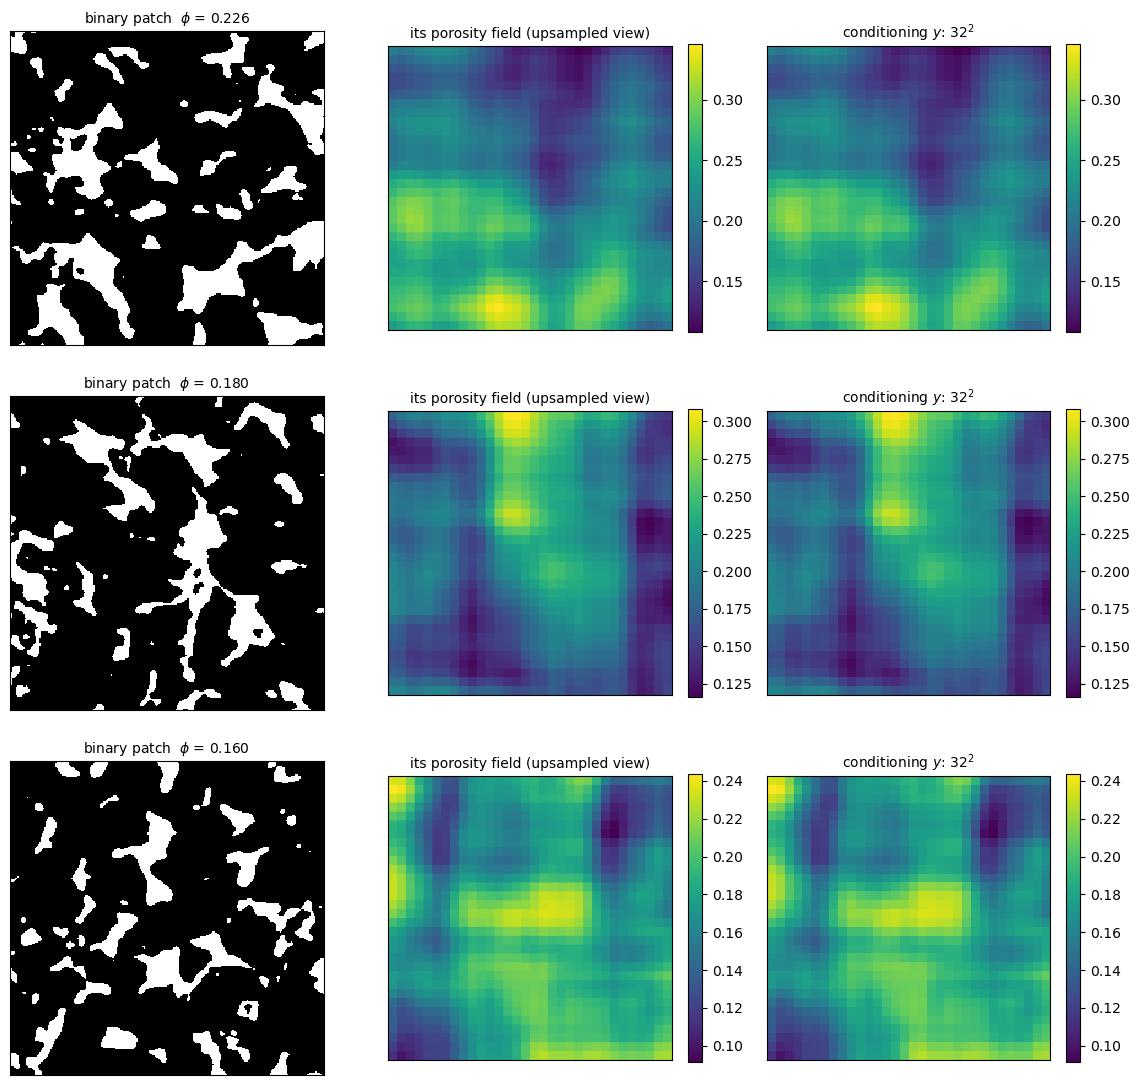

In [7]:
def draw_pair(dataset, n=3, name=None):
    fig, axes = plt.subplots(n, 3, figsize=(11.5, 3.7 * n))
    axes = np.atleast_2d(axes)
    for k in range(n):
        item = dataset[k]
        x = item['x'][0].numpy()
        phi_lat = item['y']['porosity'].numpy()
        # re-derive the pixel-resolution field for display only
        phi_px = np.kron(phi_lat, np.ones((fc.F, fc.F)))

        axes[k, 0].imshow(x, cmap='gray_r', interpolation='nearest')
        axes[k, 0].set_title(f"binary patch  $\\phi$ = {1 - x.mean():.3f}", fontsize=10)

        im = axes[k, 1].imshow(phi_px, cmap='viridis')
        axes[k, 1].set_title("its porosity field (upsampled view)", fontsize=10)
        fig.colorbar(im, ax=axes[k, 1], fraction=0.046)

        im = axes[k, 2].imshow(phi_lat, cmap='viridis', interpolation='nearest')
        axes[k, 2].set_title(f"conditioning $y$: {phi_lat.shape[0]}$^2$", fontsize=10)
        fig.colorbar(im, ax=axes[k, 2], fraction=0.046)

    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    if name:
        fc.savefig(fig, name)
    plt.show()


draw_pair(train_dataset, n=3, name="03_training_pairs")

### Why the symmetry must be shared

If the patch is rotated but the field is not, the model is asked to place high porosity
where the field says low. Below: the correlation between the pooled conditioning field and
the patch's *own* local porosity, computed both ways.

In [8]:
def pooled_local_porosity(x, factor=fc.F):
    '''Local porosity of the binary patch itself, on the latent grid.'''
    pore = 1.0 - x
    return F.avg_pool2d(pore[None, None], factor, factor)[0, 0]


rng = np.random.default_rng(0)
corr_ok, corr_bad = [], []
for _ in range(40):
    s = rng.integers(0, train_bin.shape[0])
    i = rng.integers(0, train_bin.shape[1] - fc.PATCH + 1)
    j = rng.integers(0, train_bin.shape[2] - fc.PATCH + 1)
    sl = (slice(i, i + fc.PATCH), slice(j, j + fc.PATCH))
    x0 = torch.from_numpy(train_bin[s][sl].copy()).float()
    p0 = torch.from_numpy(train_phi[s][sl].copy()).float()

    a, b = int(rng.integers(1, 8)), 0
    x_a = symmetry.apply(x0, a)
    p_same = symmetry.apply(p0, a)      # correct: same id
    p_diff = symmetry.apply(p0, b)      # wrong: different id

    local = pooled_local_porosity(x_a).numpy().ravel()
    for store, p in [(corr_ok, p_same), (corr_bad, p_diff)]:
        cond = F.avg_pool2d(p[None, None], fc.F, fc.F)[0, 0].numpy().ravel()
        store.append(np.corrcoef(local, cond)[0, 1])

print(f"same symmetry on both      : rho = {np.mean(corr_ok):+.3f}")
print(f"different symmetries       : rho = {np.mean(corr_bad):+.3f}   <- the signal is destroyed")

same symmetry on both      : rho = +0.164
different symmetries       : rho = +0.013   <- the signal is destroyed


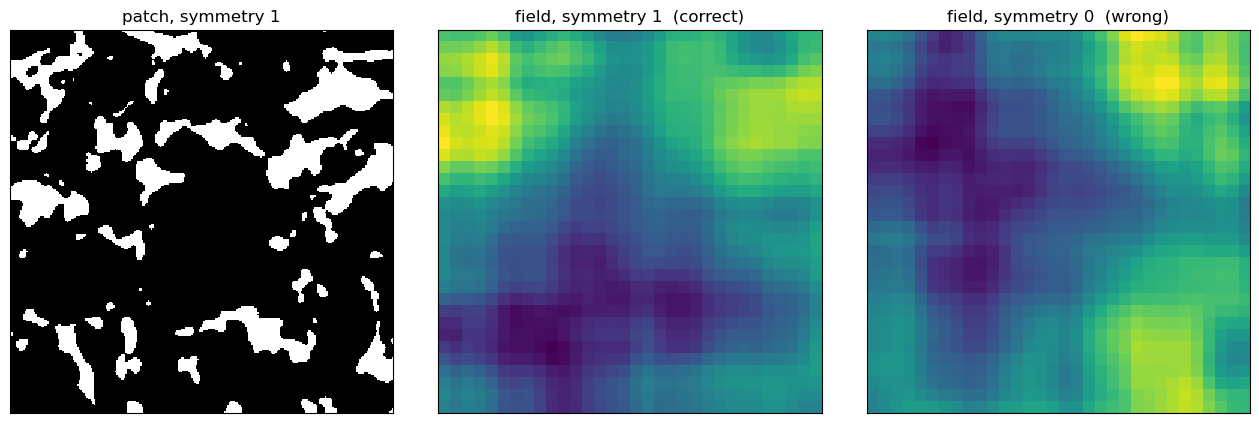

In [9]:
# The same point, as a picture.
s, i, j = 0, 300, 300
sl = (slice(i, i + fc.PATCH), slice(j, j + fc.PATCH))
x0 = torch.from_numpy(train_bin[s][sl].copy()).float()
p0 = torch.from_numpy(train_phi[s][sl].copy()).float()
sym_id = 1

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(symmetry.apply(x0, sym_id), cmap='gray_r', interpolation='nearest')
axes[0].set_title(f"patch, symmetry {sym_id}")
axes[1].imshow(F.avg_pool2d(symmetry.apply(p0, sym_id)[None, None], fc.F, fc.F)[0, 0],
               cmap='viridis', interpolation='nearest')
axes[1].set_title(f"field, symmetry {sym_id}  (correct)")
axes[2].imshow(F.avg_pool2d(symmetry.apply(p0, 0)[None, None], fc.F, fc.F)[0, 0],
               cmap='viridis', interpolation='nearest')
axes[2].set_title("field, symmetry 0  (wrong)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fc.savefig(fig, "03_symmetry_alignment")
plt.show()

---
## 3. Fine-tuning machinery

Two pieces from `0003-porosity-field-training.py`, small enough to read in full.

**`WarmupConstantCosineScheduler`** — linear warmup, a constant plateau, then a cosine
decay to zero over the last epochs. Warmup matters because the first gradients on a *new
conditioning modality* are large and would otherwise damage the pretrained features.

**`EMACallback`** — an exponential moving average of the weights, evaluated at validation
time. Diffusion training is noisy; the averaged weights usually sample better than the raw
ones.

In [10]:
class WarmupConstantCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    '''[0, warmup): linear rise.  [warmup, decay_start): constant.  then: cosine to 0.'''

    def __init__(self, optimizer, warmup_steps, total_steps=None, cosine_decay_steps=0):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.cosine_decay_steps = cosine_decay_steps
        self.decay_start = (total_steps - cosine_decay_steps
                            if total_steps is not None and cosine_decay_steps > 0 else None)
        super().__init__(optimizer)

    def get_lr(self):
        step = self.last_epoch
        if step < self.warmup_steps:
            factor = (step + 1) / self.warmup_steps
        elif self.decay_start is not None and step >= self.decay_start:
            progress = (step - self.decay_start) / max(1, self.cosine_decay_steps)
            factor = 0.5 * (1 + np.cos(np.pi * progress))
        else:
            factor = 1.0
        return [base_lr * factor for base_lr in self.base_lrs]


class EMACallback(pl_callbacks.Callback):
    '''ema <- decay * ema + (1 - decay) * weights; swapped in for validation.'''

    def __init__(self, decay=0.99):
        super().__init__()
        self.decay = decay
        self.ema_weights = {}

    def on_train_start(self, trainer, pl_module):
        for name, param in pl_module.model.named_parameters():
            self.ema_weights[name] = param.data.clone()

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        with torch.no_grad():
            for name, param in pl_module.model.named_parameters():
                if name in self.ema_weights:
                    self.ema_weights[name].mul_(self.decay).add_(param.data, alpha=1 - self.decay)

    def on_validation_start(self, trainer, pl_module):
        self._swap(pl_module)

    def on_validation_end(self, trainer, pl_module):
        self._swap(pl_module)

    def _swap(self, pl_module):
        with torch.no_grad():
            for name, param in pl_module.model.named_parameters():
                if name in self.ema_weights:
                    tmp = param.data.clone()
                    param.data.copy_(self.ema_weights[name])
                    self.ema_weights[name].copy_(tmp)


print("scheduler and EMA defined")

scheduler and EMA defined


---
## 4. Fine-tune

We start from the scalar checkpoint — this is a *fine-tune*, not a fresh run. The network
already knows what Berea looks like and how to denoise it; what it has to learn is that
the conditioning signal now varies across the image.

In [11]:
flow_model = fc.load_flow_model(SCALAR_CKPT, conditional=True)   # <- warm start
vae = fc.load_vae()
flow_module = fc.make_si_module(flow_model, autoencoder=vae)
flow_module.freeze_autoencoder()
print(f"warm-started from the scalar checkpoint "
      f"({sum(p.numel() for p in flow_module.model.parameters()) / 1e6:.2f}M trainable)")

warm-started from the scalar checkpoint (11.15M trainable)


In [12]:
if RETRAIN or not os.path.exists(CKPT):
    steps_per_epoch = len(train_loader)
    optimizer = torch.optim.AdamW(
        flow_module.model.parameters(), lr=LR, betas=(0.9, 0.999),
        weight_decay=WEIGHT_DECAY, eps=1e-8)
    scheduler = WarmupConstantCosineScheduler(
        optimizer,
        warmup_steps=WARMUP_EPOCHS * steps_per_epoch,
        total_steps=MAX_EPOCHS * steps_per_epoch,
        cosine_decay_steps=COSINE_DECAY_EPOCHS * steps_per_epoch)
    flow_module.set_optimizer_and_scheduler(
        optimizer=optimizer, scheduler=scheduler, scheduler_interval="step")

    trainer = lightning.Trainer(
        max_epochs=MAX_EPOCHS,
        default_root_dir=fc.FIELD_CKPT_DIR,
        gradient_clip_val=GRAD_CLIP,
        callbacks=[
            diffsci2.models.NanToZeroGradCallback(),
            pl_callbacks.ModelCheckpoint(
                dirpath=fc.FIELD_CKPT_DIR,
                filename='field-{epoch:03d}-{val_loss:.5f}',
                monitor='val_loss', mode='min', save_top_k=2, save_last=True),
            EMACallback(decay=EMA_DECAY),
            pl_callbacks.LearningRateMonitor(logging_interval='step'),
        ],
        devices=[int(DEVICE.split(':')[1])],
        precision='16-mixed',
        logger=lightning.pytorch.loggers.CSVLogger(fc.FIELD_CKPT_DIR, name='logs'),
        log_every_n_steps=20,
    )
    t0 = time.time()
    trainer.fit(flow_module, train_loader, val_loader)
    print(f"fine-tuned in {(time.time() - t0) / 60:.1f} min")
else:
    print("checkpoint found, skipping training (set RETRAIN = True to force)")

checkpoint found, skipping training (set RETRAIN = True to force)


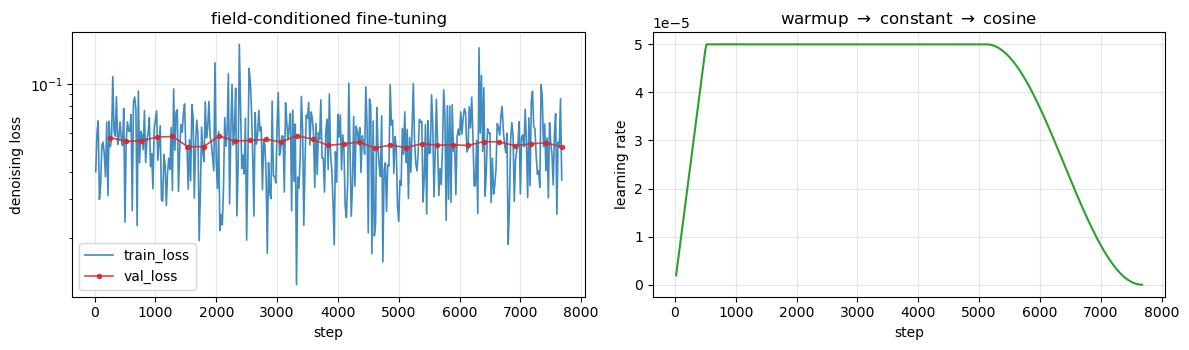

In [13]:
import glob
import pandas as pd

logs = sorted(glob.glob(os.path.join(fc.FIELD_CKPT_DIR, 'logs', '*', 'metrics.csv')))
if logs:
    dfm = pd.read_csv(logs[-1])
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    for col, style in [('train_loss', 'C0-'), ('val_loss', 'C3o-')]:
        if col in dfm.columns:
            sub = dfm[['step', col]].dropna()
            axes[0].plot(sub['step'], sub[col], style, lw=1.2, ms=3, label=col, alpha=0.85)
    axes[0].set_xlabel("step"); axes[0].set_ylabel("denoising loss"); axes[0].set_yscale('log')
    axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title("field-conditioned fine-tuning")
    if 'lr-AdamW' in dfm.columns:
        sub = dfm[['step', 'lr-AdamW']].dropna()
        axes[1].plot(sub['step'], sub['lr-AdamW'], 'C2-')
        axes[1].set_xlabel("step"); axes[1].set_ylabel("learning rate")
        axes[1].set_title("warmup $\\to$ constant $\\to$ cosine"); axes[1].grid(alpha=0.3)
    fig.tight_layout()
    fc.savefig(fig, "03_loss_curves")
    plt.show()
else:
    print("no CSV logs in this directory")

---
## 5. Did it take?

The immediate test, before any Gaussian process is involved: take a **real** field from a
*validation* slice, hand it to the model as conditioning, and compare the field the model
produced against the field it was asked for.

This isolates the conditional model $\mu^\theta(\omega|\phi)$ from the field model
$\mu_\phi$ — notebook 04 puts the two together.

In [14]:
field_model = fc.load_flow_model(CKPT, conditional=True)
module = fc.make_si_module(field_model, autoencoder=fc.load_vae()).to(DEVICE).eval()


@torch.no_grad()
def generate_with_field(module, phi_latent, nsteps=fc.NSTEPS, seed=None):
    """phi_latent: [h, w] numpy in (0,1)  ->  binary image of shape [8h, 8w]."""
    if seed is not None:
        torch.manual_seed(seed)
    y = {'porosity': torch.tensor(phi_latent, dtype=torch.float32)}
    img = module.sample(1, shape=[fc.Z_DIM, *phi_latent.shape], y=y, nsteps=nsteps,
                        is_latent_shape=True, return_latents=False, guidance=1.0)
    arr = img[0, 0].cpu().numpy()
    return (arr > arr.mean()).astype(np.float32)


def latent_field_of(binary, window=fc.WINDOW, factor=fc.F):
    """Realised porosity field of a binary image, on the latent grid.

    This MUST use the same definition of "porosity field" as the conditioning:
    a local average over a window of `window` voxels, and only then pooled by F.

    Pooling the binary image straight down by F instead gives the pore fraction of
    each F x F block -- a window-8 field. That is a different quantity, and not a
    small difference: on real rock it correlates with the true window-129 field at
    only rho ~ 0.18, so it would cap the measured tracking of *any* generator.
    The self-test in the next cell checks this rather than assuming it.

    Mirrors scripts/old/0007-porosity-field-evaluation.py:
        calculate_porosity_field_full(volume, w) -> average_volume(field, F)
    """
    return fc.realised_field(binary, window=window, factor=factor)


# A real conditioning field taken from a held-out slice.
SIZE = 512
ls = SIZE // fc.F
v = 0
phi_real = val_phi[v][:SIZE, :SIZE]
phi_cond = fc.to_latent(phi_real)
ref_binary = val_bin[v][:SIZE, :SIZE].astype(np.float32)

t0 = time.time()
gen = generate_with_field(module, phi_cond, seed=11)
print(f"generated {gen.shape} in {time.time() - t0:.1f}s")

phi_gen = latent_field_of(gen)

# The 'same'-mode field averaged over fewer than w^2 real voxels within R of the
# border, so every comparison below uses the interior only.
phi_cond_i, phi_gen_i = fc.field_interior(phi_cond), fc.field_interior(phi_gen)
rho = np.corrcoef(phi_cond_i.ravel(), phi_gen_i.ravel())[0, 1]
print(f"requested phi : mean {phi_cond_i.mean():.4f}  std {phi_cond_i.std():.4f}")
print(f"realised  phi : mean {phi_gen_i.mean():.4f}  std {phi_gen_i.std():.4f}")
print(f"voxel-wise field correlation rho = {rho:.3f}")

/opt/persistence/repos/DiffSci2/diffsci2/models/karras/flowfield.py:897: UserWarning: Moving y to device: cuda:2
  warnings.warn("Moving y to device: {}".format(self.device))


generated (512, 512) in 1.0s
requested phi : mean 0.2089  std 0.0477
realised  phi : mean 0.2051  std 0.0496
voxel-wise field correlation rho = 0.959


In [15]:
# Self-test: feed the REAL image through latent_field_of. Since the stored field was
# computed from that same image, the result must reproduce it -- rho = 1. This is the
# check that catches a mismatched field definition.
_check = latent_field_of(ref_binary)
_a, _b = fc.field_interior(phi_cond), fc.field_interior(_check)
print(f"realised field of the REAL image vs its own conditioning field:")
print(f"  rho = {np.corrcoef(_a.ravel(), _b.ravel())[0, 1]:+.4f}   "
      f"max|diff| = {np.abs(_a - _b).max():.2e}      <- must be 1.0000")

# What the naive alternative would have given:
_wrong = F.avg_pool2d(torch.from_numpy(1.0 - ref_binary)[None, None], fc.F, fc.F)[0, 0].numpy()
_w = fc.field_interior(_wrong)
print(f"  avg_pool{fc.F}(binary) instead: rho = {np.corrcoef(_a.ravel(), _w.ravel())[0, 1]:+.4f}, "
      f"std {_w.std():.4f} vs {_a.std():.4f}  <- a window-{fc.F} field, not window-{fc.WINDOW}")

realised field of the REAL image vs its own conditioning field:
  rho = +1.0000   max|diff| = 3.20e-05      <- must be 1.0000
  avg_pool8(binary) instead: rho = +0.1537, std 0.3247 vs 0.0477  <- a window-8 field, not window-129


In [16]:
latent_field_of??

Signature: latent_field_of(binary, window=129, factor=8)
Source:   
def latent_field_of(binary, window=fc.WINDOW, factor=fc.F):
    """Realised porosity field of a binary image, on the latent grid.

    This MUST use the same definition of "porosity field" as the conditioning:
    a local average over a window of `window` voxels, and only then pooled by F.

    Pooling the binary image straight down by F instead gives the pore fraction of
    each F x F block -- a window-8 field. That is a different quantity, and not a
    small difference: on real rock it correlates with the true window-129 field at
    only rho ~ 0.18, so it would cap the measured tracking of *any* generator.
    The self-test in the next cell checks this rather than assuming it.

    Mirrors scripts/old/0007-porosity-field-evaluation.py:
        calculate_porosity_field_full(volume, w) -> average_volume(field, F)
    """
    return fc.realised_field(binary, window=window, factor=factor)
File:      /tmp/ipykernel_894

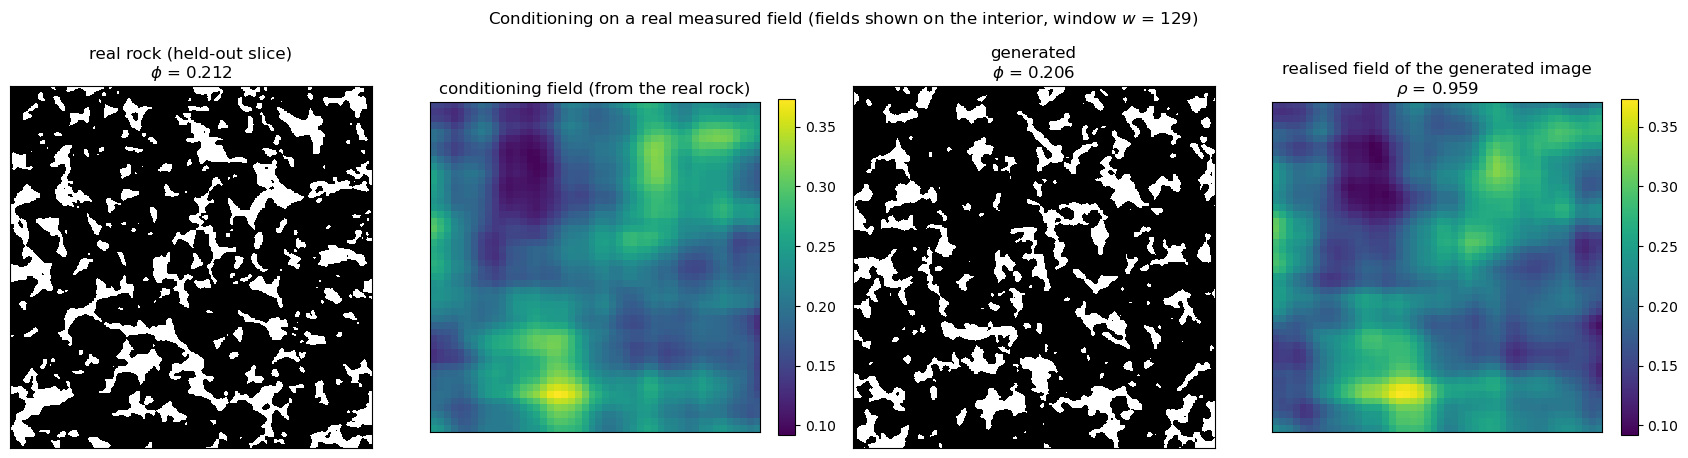

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
vmin, vmax = min(phi_cond_i.min(), phi_gen_i.min()), max(phi_cond_i.max(), phi_gen_i.max())

axes[0].imshow(ref_binary, cmap='gray_r', interpolation='nearest')
axes[0].set_title(f"real rock (held-out slice)\n$\\phi$ = {1 - ref_binary.mean():.3f}")

im = axes[1].imshow(phi_cond_i, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
axes[1].set_title("conditioning field (from the real rock)")
fig.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(gen, cmap='gray_r', interpolation='nearest')
axes[2].set_title(f"generated\n$\\phi$ = {1 - gen.mean():.3f}")

im = axes[3].imshow(phi_gen_i, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
axes[3].set_title(f"realised field of the generated image\n$\\rho$ = {rho:.3f}")
fig.colorbar(im, ax=axes[3], fraction=0.046)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Conditioning on a real measured field "
             f"(fields shown on the interior, window $w$ = {fc.WINDOW})", y=1.03)
fig.tight_layout()
fc.savefig(fig, "03_conditioning_on_real_field")
plt.show()

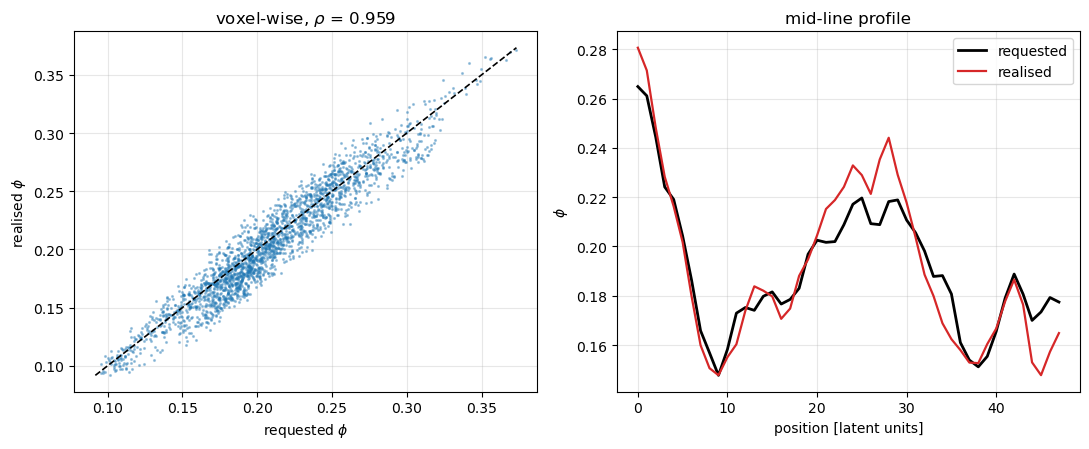

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].plot(phi_cond_i.ravel(), phi_gen_i.ravel(), '.', ms=2.5, alpha=0.35, color='C0')
lims = [vmin, vmax]
axes[0].plot(lims, lims, 'k--', lw=1.2)
axes[0].set_xlabel("requested $\\phi$"); axes[0].set_ylabel("realised $\\phi$")
axes[0].set_title(f"voxel-wise, $\\rho$ = {rho:.3f}"); axes[0].grid(alpha=0.3)

mid = phi_cond_i.shape[0] // 2
axes[1].plot(phi_cond_i[mid], 'k-', lw=2, label='requested')
axes[1].plot(phi_gen_i[mid], 'C3-', lw=1.6, label='realised')
axes[1].set_xlabel("position [latent units]"); axes[1].set_ylabel("$\\phi$")
axes[1].set_title("mid-line profile"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
fc.savefig(fig, "03_field_tracking")
plt.show()

The correlation will be strong but **not** 1, and that is the expected behaviour, not a
defect. The field is a *soft constraint*: the model is asked to produce microstructure
whose local porosity resembles $\phi$, not to reproduce $\phi$ exactly. The thesis makes
the same observation for the 3D case — the sub-block statistics match while the
voxel-wise field match remains partial.

### A control: does the same model still respond to a *different* field?

If the model had simply memorised "Berea looks like this" and ignored the conditioning, the
generated field would be the same regardless of what we asked for. Here we feed it a
deliberately structured field it has never seen.

/opt/persistence/repos/DiffSci2/diffsci2/models/karras/flowfield.py:897: UserWarning: Moving y to device: cuda:2
  warnings.warn("Moving y to device: {}".format(self.device))


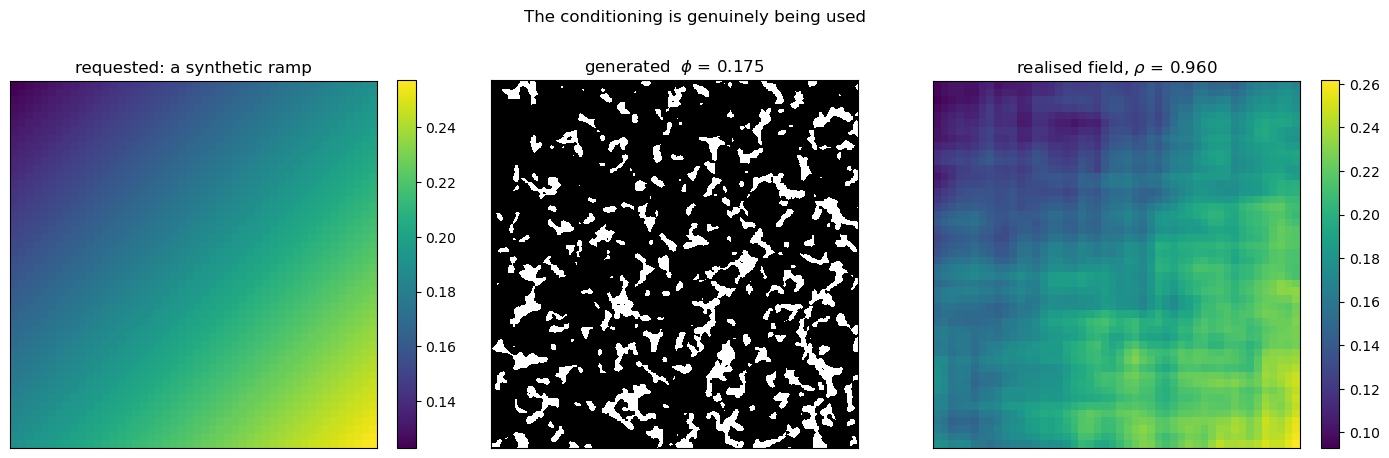

In [19]:
# A synthetic field: a smooth diagonal ramp between two porosity levels.
yy, xx = np.meshgrid(np.linspace(0, 1, ls), np.linspace(0, 1, ls), indexing='ij')
phi_ramp = (0.10 + 0.18 * (0.5 * (xx + yy))).astype(np.float32)

gen_ramp = generate_with_field(module, phi_ramp, seed=5)
phi_ramp_out = latent_field_of(gen_ramp)
ramp_in_i, ramp_out_i = fc.field_interior(phi_ramp), fc.field_interior(phi_ramp_out)
rho_ramp = np.corrcoef(ramp_in_i.ravel(), ramp_out_i.ravel())[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
im = axes[0].imshow(ramp_in_i, cmap='viridis', interpolation='nearest')
axes[0].set_title("requested: a synthetic ramp"); fig.colorbar(im, ax=axes[0], fraction=0.046)
axes[1].imshow(gen_ramp, cmap='gray_r', interpolation='nearest')
axes[1].set_title(f"generated  $\\phi$ = {1 - gen_ramp.mean():.3f}")
im = axes[2].imshow(ramp_out_i, cmap='viridis', interpolation='nearest')
axes[2].set_title(f"realised field, $\\rho$ = {rho_ramp:.3f}"); fig.colorbar(im, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The conditioning is genuinely being used", y=1.03)
fig.tight_layout()
fc.savefig(fig, "03_synthetic_ramp_control")
plt.show()

### Was the fine-tuning necessary? — pretrained vs post-trained

The architecture never changed, so the **pretrained** scalar-conditioned model from
notebook 02 accepts a $32^2$ field just as happily as the fine-tuned one does. What it
never saw is training data in which the conditioning *varied across the image*: every
example it was shown had a single porosity value covering the whole patch.

That lets us isolate the effect of the fine-tune exactly. Same conditioning field, same
random seed — hence the same initial noise — same sampler, same number of steps. **Only
the weights differ.**

This is the pair of generation cases the thesis compares in
`0004e-porosity-field-generator.py`: **case 4** (field conditioning, scalar-trained model)
against **case 5** (field conditioning, field-trained model).

In [ ]:
# The pretrained model, straight from notebook 02's checkpoint.
pre_model = fc.load_flow_model(SCALAR_CKPT, conditional=True)
pre_module = fc.make_si_module(pre_model, autoencoder=fc.load_vae()).to(DEVICE).eval()

# Same fields and same seeds as the post-trained runs above, so the only difference
# between the two rows of the figure below is the weights.
t0 = time.time()
gen_pre = generate_with_field(pre_module, phi_cond, seed=11)
gen_ramp_pre = generate_with_field(pre_module, phi_ramp, seed=5)
print(f"pretrained generations in {time.time() - t0:.1f}s")

phi_gen_pre_i = fc.field_interior(latent_field_of(gen_pre))
ramp_out_pre_i = fc.field_interior(latent_field_of(gen_ramp_pre))

rho_pre = np.corrcoef(phi_cond_i.ravel(), phi_gen_pre_i.ravel())[0, 1]
rho_ramp_pre = np.corrcoef(ramp_in_i.ravel(), ramp_out_pre_i.ravel())[0, 1]

print(f"\n{'model':<24} {'rho (real field)':>17} {'rho (ramp)':>12} "
      f"{'realised std':>13} {'mean phi':>10}")
print(f"{'requested':<24} {'--':>17} {'--':>12} "
      f"{phi_cond_i.std():>13.4f} {phi_cond_i.mean():>10.4f}")
print(f"{'pretrained (scalar)':<24} {rho_pre:>17.3f} {rho_ramp_pre:>12.3f} "
      f"{phi_gen_pre_i.std():>13.4f} {phi_gen_pre_i.mean():>10.4f}")
print(f"{'post-trained (field)':<24} {rho:>17.3f} {rho_ramp:>12.3f} "
      f"{phi_gen_i.std():>13.4f} {phi_gen_i.mean():>10.4f}")

In [ ]:
cases = [
    ("measured field\n(held-out rock)", phi_cond_i, gen_pre, phi_gen_pre_i, gen, phi_gen_i,
     rho_pre, rho),
    ("synthetic ramp", ramp_in_i, gen_ramp_pre, ramp_out_pre_i, gen_ramp, ramp_out_i,
     rho_ramp_pre, rho_ramp),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8.6))
for r, (name, phi_in, g_pre, f_pre, g_post, f_post, r_pre, r_post) in enumerate(cases):
    vmin = min(phi_in.min(), f_pre.min(), f_post.min())
    vmax = max(phi_in.max(), f_pre.max(), f_post.max())

    im = axes[r, 0].imshow(phi_in, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[r, 0].set_title(f"requested $\\phi$\n{name}", fontsize=10)
    fig.colorbar(im, ax=axes[r, 0], fraction=0.046)

    axes[r, 1].imshow(g_pre, cmap='gray_r', interpolation='nearest')
    axes[r, 1].set_title(f"pretrained: generated\n$\\phi$ = {1 - g_pre.mean():.3f}", fontsize=10)
    im = axes[r, 2].imshow(f_pre, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[r, 2].set_title(f"pretrained: realised $\\phi$\n$\\rho$ = {r_pre:.3f}", fontsize=10)
    fig.colorbar(im, ax=axes[r, 2], fraction=0.046)

    axes[r, 3].imshow(g_post, cmap='gray_r', interpolation='nearest')
    axes[r, 3].set_title(f"post-trained: generated\n$\\phi$ = {1 - g_post.mean():.3f}", fontsize=10)
    im = axes[r, 4].imshow(f_post, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[r, 4].set_title(f"post-trained: realised $\\phi$\n$\\rho$ = {r_post:.3f}", fontsize=10)
    fig.colorbar(im, ax=axes[r, 4], fraction=0.046)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Same field, same noise, same architecture — only the weights differ "
             "(case 4 vs case 5)", y=0.98)
fig.tight_layout()
fc.savefig(fig, "03_pretrained_vs_posttrained")
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

axes[0].plot(phi_cond_i.ravel(), phi_gen_pre_i.ravel(), '.', ms=2, alpha=0.28, color='C7',
             label=f'pretrained  $\\rho$ = {rho_pre:.3f}')
axes[0].plot(phi_cond_i.ravel(), phi_gen_i.ravel(), '.', ms=2, alpha=0.28, color='C0',
             label=f'post-trained  $\\rho$ = {rho:.3f}')
lo = min(phi_cond_i.min(), phi_gen_pre_i.min(), phi_gen_i.min())
hi = max(phi_cond_i.max(), phi_gen_pre_i.max(), phi_gen_i.max())
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='identity')
axes[0].set_xlabel("requested $\\phi$"); axes[0].set_ylabel("realised $\\phi$")
axes[0].set_title("measured field"); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, markerscale=5)

mid = ramp_in_i.shape[0] // 2
axes[1].plot(ramp_in_i[mid], 'k-', lw=2.4, label='requested ramp')
axes[1].plot(ramp_out_pre_i[mid], color='C7', lw=1.7,
             label=f'pretrained ($\\rho$ = {rho_ramp_pre:.3f})')
axes[1].plot(ramp_out_i[mid], color='C0', lw=1.7,
             label=f'post-trained ($\\rho$ = {rho_ramp:.3f})')
axes[1].set_xlabel("position [latent units]"); axes[1].set_ylabel("$\\phi$")
axes[1].set_title("mid-line profile across the ramp")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.tight_layout()
fc.savefig(fig, "03_pretrained_vs_posttrained_tracking")
plt.show()

Read the two $\rho$ columns printed above; they settle the question rather than the
prose doing it. The mechanism to expect: the pretrained model was only ever rewarded for
matching a *global* porosity, so a field is, to it, roughly a strangely-encoded scalar —
it should track the overall level but respond weakly to where the field is high or low.
The ramp is the sharper test of the two, because a model that ignores spatial structure
has nowhere to hide: it will produce a uniform image where a gradient was asked for.

Two caveats worth keeping in mind when reading these numbers:

- $\rho$ is not bounded by 1 in practice — the field is a *soft* constraint, and even a
  perfectly fine-tuned model produces microstructure whose realised field only resembles
  the requested one. Notebook 04 quantifies this at generation scale.
- a single sample per model per field. Treat the gap as indicative; the sample-to-sample
  spread is measured properly in notebook 04.

### Why did the loss barely move?

The fine-tune changes behaviour qualitatively, yet its loss curve is nearly flat:
train loss went $0.0564 \to 0.0549$ (2.6%), and its *first* validation already sat at
the pretrained model's converged level. The weights moved only 7.5% in relative $L_2$ —
and, against intuition, **least of all in the conditioning embedder** (1.7%); most of the
drift is in the UNet bottleneck and the resampling layers.

That combination is only confusing if you assume the denoising loss measures how well the
model follows the field. It does not necessarily, and this section measures how much it
can see at all.

The objective is $\lambda(\sigma)\lVert D_\theta(z_\sigma,\sigma,y) - z\rVert^2$. Almost
all of that error is irreducible — at a given $\sigma$ the noise simply cannot be removed.
Conditioning can only help predict the *large-scale, low-frequency* part of $z$, a small
share of its variance. So a perfect field-follower and a field-ignorer may differ by a
couple of percent of loss while their samples differ obviously.

The probe holds everything fixed — same latents, same noise, same $\sigma$, same frozen
VAE — and varies only the conditioning:

| variant | what it removes |
|---|---|
| `field (correct)` | nothing |
| `field, mismatched` | the spatial correspondence (another patch's field, same marginals) |
| `flat = own mean` | the spatial *structure*, keeping the correct overall level |
| `none` | the conditioning entirely |

`flat = own mean` is the one to watch: its gap to `field (correct)` is exactly the part of
the loss that **spatial** conditioning information can explain.

In [ ]:
# A fixed probe set: identical latents, noise and sigmas for every variant and both
# models, so nothing but the conditioning (and the weights) can move the loss.
N_PROBE_BATCHES, PROBE_BS = 12, 8
probe_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=PROBE_BS, shuffle=False, num_workers=0)

torch.manual_seed(0)
probe = []
with torch.no_grad():
    for k, b in enumerate(probe_loader):
        if k >= N_PROBE_BATCHES:
            break
        z, _ = module.encode(b['x'].to(DEVICE), None)   # frozen VAE, shared by both models
        z = module.initial_norm(z)
        probe.append((z, b['y']['porosity'].to(DEVICE), torch.randn_like(z)))
print(f"probe: {len(probe)} batches x {PROBE_BS}, latent {tuple(probe[0][0].shape[1:])}")

# In this config t IS sigma, so we can probe the noise levels the sampler visits.
SIGMAS = module.create_time_schedule(13).cpu().numpy()[:-1]
print(f"sigma grid: {np.array2string(SIGMAS, precision=3)}")


def conditioning_variants(phi):
    """Four conditionings with the same marginals but different spatial information."""
    return [
        ('field (correct)',   {'porosity': phi}),
        ('field, mismatched', {'porosity': phi.roll(1, 0)}),
        ('flat = own mean',   {'porosity': phi.mean(dim=(1, 2), keepdim=True).expand_as(phi)}),
        ('none',              None),
    ]


VARIANTS = [n for n, _ in conditioning_variants(probe[0][1])]


@torch.no_grad()
def loss_vs_sigma(mod):
    """EDM-weighted denoising loss per sigma, per conditioning variant."""
    mod.eval()
    out = {n: np.zeros(len(SIGMAS)) for n in VARIANTS}
    for z, phi, noise in probe:
        for si, s in enumerate(SIGMAS):
            t = torch.full((z.shape[0],), float(s), device=DEVICE)
            alpha = mod.config.alpha_fn(t).view(-1, 1, 1, 1)
            sigma = mod.config.sigma_fn(t).view(-1, 1, 1, 1)
            z_sig = alpha * z + sigma * noise
            w = mod.config.loss_weighting.weighting_function(t.view(-1, 1, 1, 1))
            for name, y in conditioning_variants(phi):
                d = mod.get_denoiser_output(z_sig, t, y=y)
                out[name][si] += float(
                    (mod.config.loss_metric_module(d, z) * w).mean()) / len(probe)
    return out


t0 = time.time()
sens = {'pretrained (scalar)': loss_vs_sigma(pre_module),
        'post-trained (field)': loss_vs_sigma(module)}
print(f"probed in {time.time() - t0:.0f}s")

for mname, r in sens.items():
    base = r['field (correct)'].mean()
    print(f"\n{mname}:  mean weighted loss with the correct field = {base:.5f}")
    for v in VARIANTS:
        print(f"    {v:<20} {r[v].mean():.5f}   {100 * (r[v].mean() - base) / base:+7.2f}%")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17.5, 4.6))

for ax, (mname, r) in zip(axes[:2], sens.items()):
    for v, c in zip(VARIANTS, ['C0', 'C3', 'C1', 'C7']):
        ax.plot(SIGMAS, r[v], 'o-', color=c, lw=1.8, ms=4, label=v)
    ax.set_xscale('log')
    ax.set_xlabel("$\\sigma$"); ax.set_ylabel("weighted denoising loss")
    ax.set_title(mname); ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

ax = axes[2]
for (mname, r), c, mk in zip(sens.items(), ['C7', 'C0'], ['s--', 'o-']):
    gap = 100 * (r['flat = own mean'] - r['field (correct)']) / r['field (correct)']
    ax.plot(SIGMAS, gap, mk, color=c, lw=2, ms=4, label=mname)
ax.axhline(0, color='k', lw=0.8)
ax.set_xscale('log'); ax.set_xlabel("$\\sigma$")
ax.set_ylabel("loss penalty for removing\nspatial information [%]")
ax.set_title("How much the loss can even see the field")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

fig.tight_layout()
fc.savefig(fig, "03_conditioning_loss_sensitivity")
plt.show()

The numbers above distinguish two readings, so let them decide:

- **If the `flat = own mean` penalty is small (a few percent) for the post-trained model**,
  the loss essentially cannot see the conditioning. A flat fine-tuning curve then tells you
  nothing about *when* the model learned to follow the field — what converged was the loss,
  not the behaviour. This would also explain why the fine-tune's first validation already
  sat at the pretrained level.
- **If the penalty is large**, the loss does track conditioning quality, and fast
  convergence really does mean the field was learned quickly — consistent with the small
  weight change, i.e. the capability was largely present and only needed routing.

Also look at *where* in $\sigma$ the penalty lives. Conditioning should matter most at
large $\sigma$, where the large-scale structure of the sample is still undetermined; at
small $\sigma$ the answer is already contained in $z_\sigma$ and the field is redundant. A
penalty peaked at large $\sigma$ but averaging to nearly nothing is the signature of a loss
dominated by noise levels at which conditioning is irrelevant.

Two caveats before drawing conclusions:

- the post-trained checkpoint holds **EMA** weights while the pretrained one is raw, so a
  small part of the weight-space distance is not attributable to the field task;
- the pretrained model was still drifting when it stopped (its last validation, 0.0595, is
  above its own minimum, 0.0522), so some of the fine-tune's improvement is just more
  training. A control fine-tune on **mismatched** fields for the same number of steps would
  separate the two.

**The decisive follow-up**, if you want it: checkpoint every ~50 steps for the first few
hundred steps of the fine-tune and plot $\rho$(requested, realised) against step on the
same axes as the loss. If $\rho$ saturates within a couple hundred steps while the loss
stays flat throughout, the picture is complete.

---
## What to carry forward

- Fine-tuning changed **only the data**: `y` went from a scalar to a $32^2$ array. The
  network is byte-for-byte the same architecture.
- Same location, same symmetry, pooled to the latent grid, cropped inward by $R$ — get any
  of these wrong and the conditioning signal is noise.
- We now have $\mu^\theta(\omega\,|\,\phi)$: **give it a field, get microstructure**.
- The constraint is soft. High correlation, not identity.

**Artifact written:** `fcdata/checkpoints/field/last.ckpt`.

**Next:** `04-field-controlled-inference.ipynb` — combine this with the Gaussian process
of notebook 01 and generate rock at sizes never seen in training.